# XGBoost (Extreme Gradient Boosting)

## Introduction

from markdown_it import tree


XGBoost (Extreme Gradient Boosting) is an optimized and highly efficient implementation of Gradient Boosting Machines. It is widely used in machine learning competitions and real-world applications due to its speed, scalability, and superior performance on structured/tabular data.

It improves upon traditional gradient boosting by introducing regularization, parallel computation, and system optimizations.

---

## Core Idea (Simplified)

XGBoost builds an ensemble of decision trees sequentially, where each new tree tries to correct the mistakes (residual errors) of the previous trees.

Final prediction is the sum of all tree outputs:

$$
\hat{y}*i = \sum*{k=1}^{K} f_k(x_i)
$$

where:

* $( f_k )$ = $k$-th decision tree
* $( K )$ = total number of trees

---

## Mathematical Formulation

XGBoost minimizes the following objective function:

$$
\mathcal{L} = \sum_{i=1}^{n} l(y_i, \hat{y}*i) + \sum*{k=1}^{K} \Omega(f_k)
$$

Where:

* $l(y_i, \hat{y}_i)$ = loss function (e.g., MSE, log-loss)
* $( \Omega(f) )$ = regularization term

Regularization term:

$$
\Omega(f) = \gamma T + \frac{1}{2}\lambda \sum_{j=1}^{T} w_j^2
$$

Where:

* $( T )$  = number of leaves
* $( w_j )$ = leaf weight
* $( \gamma, \lambda )$ = regularization parameters

Second-order approximation (Taylor expansion):

$$
\mathcal{L}^{(t)} \approx \sum_{i=1}^{n} \left[g_i f_t(x_i) + \frac{1}{2} h_i f_t(x_i)^2 \right] + \Omega(f_t)
$$

where:

* $( g_i = \frac{\partial l}{\partial \hat{y}_i} )$ (gradient)
* $( h_i = \frac{\partial^2 l}{\partial \hat{y}_i^2} )$ (Hessian)

---

## Mathematical Intuition

XGBoost works like a correction system:

* Start with a rough prediction
* Measure how wrong the model is (gradient)
* Use second-order information (Hessian) to understand curvature
* Build a new tree that reduces the error efficiently
* Apply regularization to prevent overfitting

Each tree is optimized to minimize the loss in a more "informed" way than standard gradient descent.

---

## Why Do We Need XGBoost?

Traditional models face limitations:

* Slow training in large datasets
* Overfitting in basic decision trees
* Weak generalization in simple boosting methods

XGBoost solves these problems by:

* Using regularization (L1 & L2) to control complexity
* Using second-order optimization for better accuracy
* Supporting parallel processing for speed
* Handling missing values automatically
* Being highly scalable

---

## Implementation (Python)

```python
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset (example: sklearn dataset)
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create XGBoost classifier
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic'
)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
```

---

## Summary

XGBoost is an advanced boosting algorithm that improves prediction accuracy through regularization, second-order optimization, and system-level optimizations. It is one of the most powerful tools for structured data machine learning problems.


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier 

In [29]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [30]:
model = XGBClassifier(
    n_estimators = 100,
    learning_rate = 3,
    subsample = 0.8,
    colsample_bytree = 0.8,
    objective = 'binary:logistic',
    eval_metric = 'logloss',
    random_state = 42
)   

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [31]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9298245614035088
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90        42
           1       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

Confusion Matrix:
 [[38  4]
 [ 4 68]]


In [32]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'eta': 0.05,
    'max_depth': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42  
}

model_xgb = xgb.train(
    params, 
    dtrain, 
    num_boost_round=500,
    evals=[(dtest, 'eval')],
    early_stopping_rounds=20,
)

[0]	eval-logloss:0.61998
[1]	eval-logloss:0.58407
[2]	eval-logloss:0.55308
[3]	eval-logloss:0.52111
[4]	eval-logloss:0.49336
[5]	eval-logloss:0.46991
[6]	eval-logloss:0.44662
[7]	eval-logloss:0.42700
[8]	eval-logloss:0.40812
[9]	eval-logloss:0.38873
[10]	eval-logloss:0.37315
[11]	eval-logloss:0.35956
[12]	eval-logloss:0.34400
[13]	eval-logloss:0.33070
[14]	eval-logloss:0.31943
[15]	eval-logloss:0.30855
[16]	eval-logloss:0.29694
[17]	eval-logloss:0.28669
[18]	eval-logloss:0.27650
[19]	eval-logloss:0.26679
[20]	eval-logloss:0.25829
[21]	eval-logloss:0.25002
[22]	eval-logloss:0.24288
[23]	eval-logloss:0.23533
[24]	eval-logloss:0.22907
[25]	eval-logloss:0.22305
[26]	eval-logloss:0.21658
[27]	eval-logloss:0.21108
[28]	eval-logloss:0.20634
[29]	eval-logloss:0.20078
[30]	eval-logloss:0.19688
[31]	eval-logloss:0.19210
[32]	eval-logloss:0.18646
[33]	eval-logloss:0.18213
[34]	eval-logloss:0.17843
[35]	eval-logloss:0.17435
[36]	eval-logloss:0.16995
[37]	eval-logloss:0.16657
[38]	eval-logloss:0.16

In [33]:
y_pred_xgb = model_xgb.predict(dtest)
y_pred_xgb_binary = (y_pred_xgb > 0.5).astype(int) 

accuracy_xgb = accuracy_score(y_test, y_pred_xgb_binary)
print("XGBoost Accuracy:", accuracy_xgb)
print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb_binary))
print("XGBoost Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_binary))

XGBoost Accuracy: 0.9649122807017544
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

XGBoost Confusion Matrix:
 [[39  3]
 [ 1 71]]


In [34]:
print("Early Stopping info: ")
print("Best iteration:", model_xgb.best_iteration)
print("Best score [logloss]:", model_xgb.best_score)

Early Stopping info: 
Best iteration: 180
Best score [logloss]: 0.08808746373050094


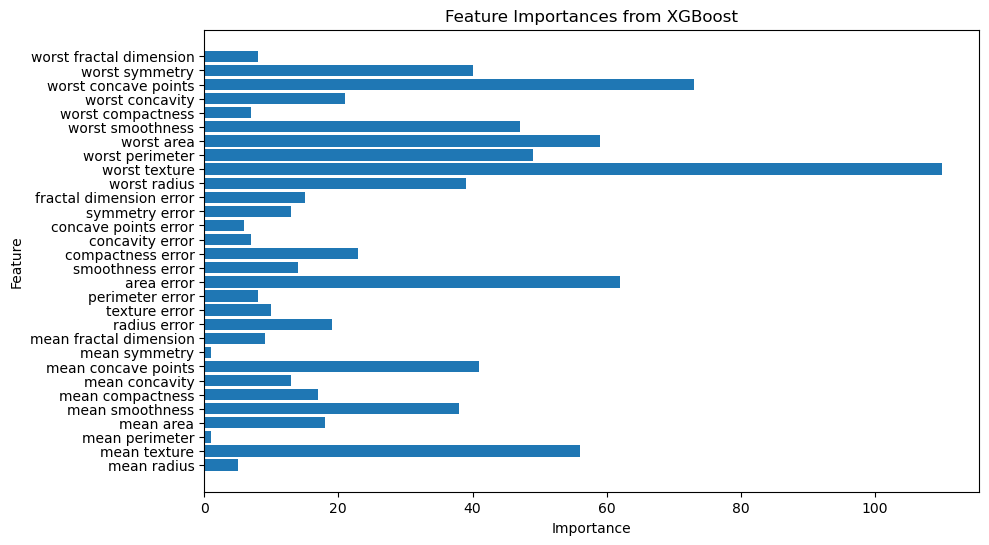

In [36]:
plt.figure(figsize=(10, 6))

plt.barh(data.feature_names, model_xgb.get_score(importance_type='weight').values())
plt.title("Feature Importances from XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()